Zara Product Performance & Sales Strategy Analysis

In [6]:
# import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
df = pd.read_csv('zara.csv', sep=";")
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,sku,name,description,price,currency,scraped_at,terms,section
0,185102,Aisle,No,Clothing,No,2823,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,272145190-250-2,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,19.99,USD,2024-02-19T08:50:05.654618,jackets,MAN
1,188771,Aisle,No,Clothing,No,654,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,324052738-800-46,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,169.00,USD,2024-02-19T08:50:06.590930,jackets,MAN
2,180176,End-cap,Yes,Clothing,Yes,2220,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,335342680-800-44,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,129.00,USD,2024-02-19T08:50:07.301419,jackets,MAN
3,112917,Aisle,Yes,Clothing,Yes,1568,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,328303236-420-44,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,129.00,USD,2024-02-19T08:50:07.882922,jackets,MAN
4,192936,End-cap,No,Clothing,Yes,2942,Zara,https://www.zara.com/us/en/double-faced-jacket...,312368260-800-2,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,139.00,USD,2024-02-19T08:50:08.453847,jackets,MAN


In [12]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 252 entries, 0 to 251
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        252 non-null    int64  
 1   Product Position  252 non-null    object 
 2   Promotion         252 non-null    object 
 3   Product Category  252 non-null    object 
 4   Seasonal          252 non-null    object 
 5   Sales Volume      252 non-null    int64  
 6   brand             252 non-null    object 
 7   url               252 non-null    object 
 8   sku               252 non-null    object 
 9   name              251 non-null    object 
 10  description       250 non-null    object 
 11  price             252 non-null    float64
 12  currency          252 non-null    object 
 13  scraped_at        252 non-null    object 
 14  terms             252 non-null    object 
 15  section           252 non-null    object 
dtypes: float64(1), int64(2), object(13)
memory u

,Product ID,Sales Volume,price
count,252.000000,252.000000,252.000000
mean,153370.503968,1823.702381,86.252540
std,26160.444549,697.703748,52.083205
min,110075.000000,529.000000,7.990000
25%,131053.750000,1243.000000,49.900000
50%,151681.500000,1839.500000,79.900000
75%,175669.750000,2398.750000,109.000000
max,199631.000000,2989.000000,439.000000


In [13]:
df.isna().sum()

,0
Product ID,0
Product Position,0
Promotion,0
Product Category,0
Seasonal,0
Sales Volume,0
brand,0
url,0
sku,0
name,1


In [16]:
df = df.dropna()

In [17]:
# KPIs
total_sales = df['Sales Volume'].sum()
median_price = df['price'].median()
total_products = df['Product ID'].nunique()
promotion_percent = (df['Promotion'].value_counts(normalize=True) * 100)

print('Total Sales:', total_sales)
print('Median Price:', median_price)
print('Total Products:', total_products)
print('Promotion %:')
print(promotion_percent)

Total Sales: 455556
Median Price: 74.945
Total Products: 250
Promotion %:
Promotion
No     52.8
Yes    47.2
Name: proportion, dtype: float64


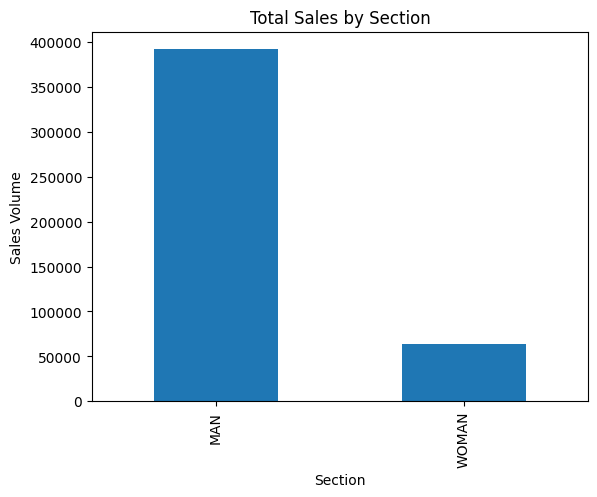

In [18]:
# Sales by Section
sales_section = df.groupby('section')['Sales Volume'].sum()

plt.figure()
sales_section.plot(kind='bar')
plt.title('Total Sales by Section')
plt.ylabel('Sales Volume')
plt.xlabel('Section')
plt.show()

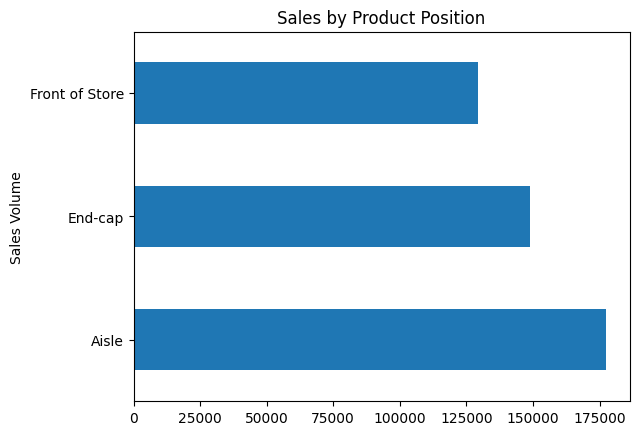

In [23]:
# Sales by Product Position
sales_position = df.groupby('Product Position')['Sales Volume'].sum()

plt.figure()
sales_position.plot(kind='barh')
plt.title('Sales by Product Position')
plt.ylabel('Sales Volume')
plt.show()

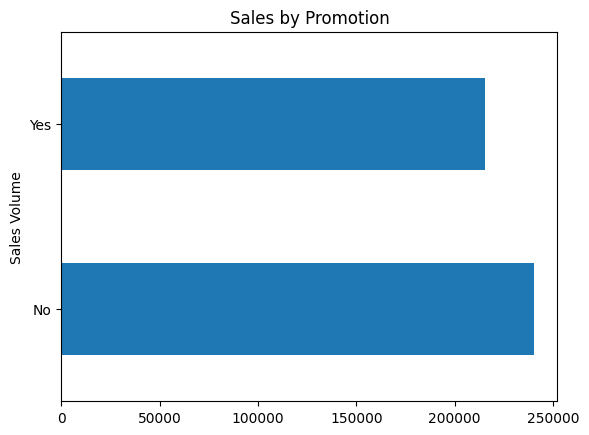

In [25]:
# Promotion Effect
promo_sales = df.groupby('Promotion')['Sales Volume'].sum()

plt.figure()
promo_sales.plot(kind='barh')
plt.title('Sales by Promotion')
plt.ylabel('Sales Volume')
plt.show()

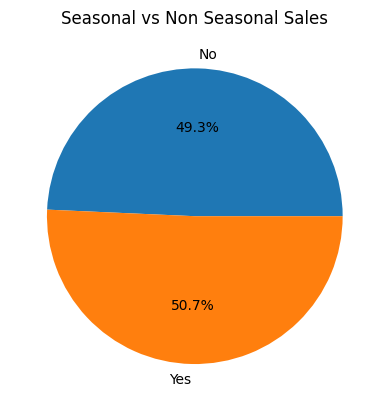

In [26]:
# Seasonal vs Non Seasonal
season_sales = df.groupby('Seasonal')['Sales Volume'].sum()

plt.figure()
season_sales.plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Seasonal vs Non Seasonal Sales')
plt.show()

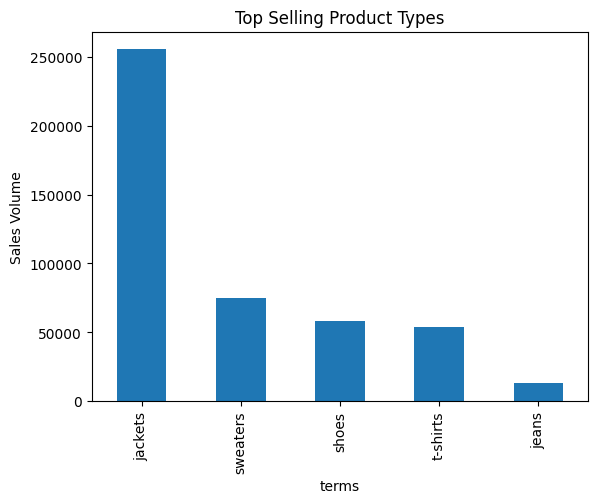

In [27]:
# Selling by Types
top_products = df.groupby('terms')['Sales Volume'].sum().sort_values(ascending=False)

plt.figure()
top_products.plot(kind='bar')
plt.title('Top Selling Product Types')
plt.ylabel('Sales Volume')
plt.show()

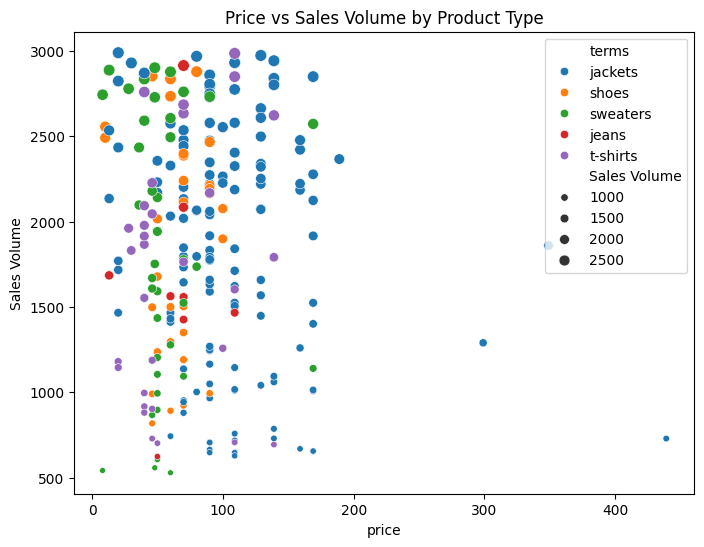

In [30]:
# Price vs Sales
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="price",
    y="Sales Volume",
    hue="terms",
    size="Sales Volume"
)

plt.title("Price vs Sales Volume by Product Type")
plt.show()